In [ ]:
!pip install qiskit matplotlib numpy

!pip install qutip
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 67.4 MB/s eta 0:00:00


PHYSICAL PARAMETERS
Qubit frequency = 5.0 GHz
T1 = 100.0 us
T2 = 80.0 us
gamma1 = 0.010000 /us
gamma_phi = 0.007500 /us

Initial density matrix

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.5]
 [0.5 0.5]]

Hamiltonian (rotating frame, 5 MHz detuning)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 15.70796327   0.        ]
 [  0.         -15.70796327]]

Simulation completed successfully!
Stored 1000 density matrices.


DENSITY MATRICES

Time = 0.00 us
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.5]
 [0.5 0.5]]
Trace = 1.0

Time = 80.08 us
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.77551536+0.j         -0.14703236-0.10505952j]
 [-0.14703236+0.10505952j  0.22448464+0.j        ]]
Trace = 1.0

Time = 100.10 us
Quantum object: dims=[[2], [2]], shape=(2, 2), type='o

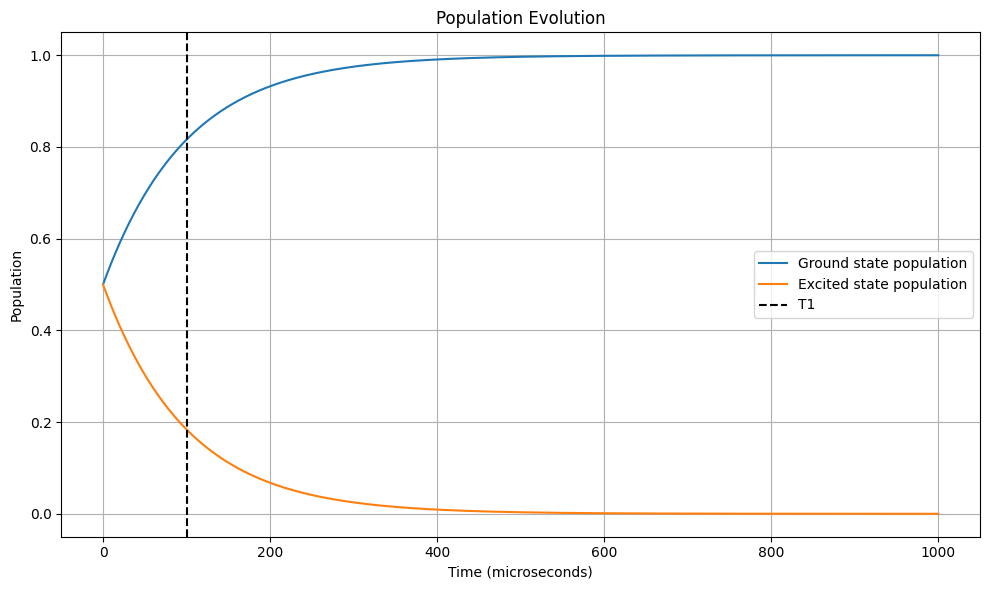

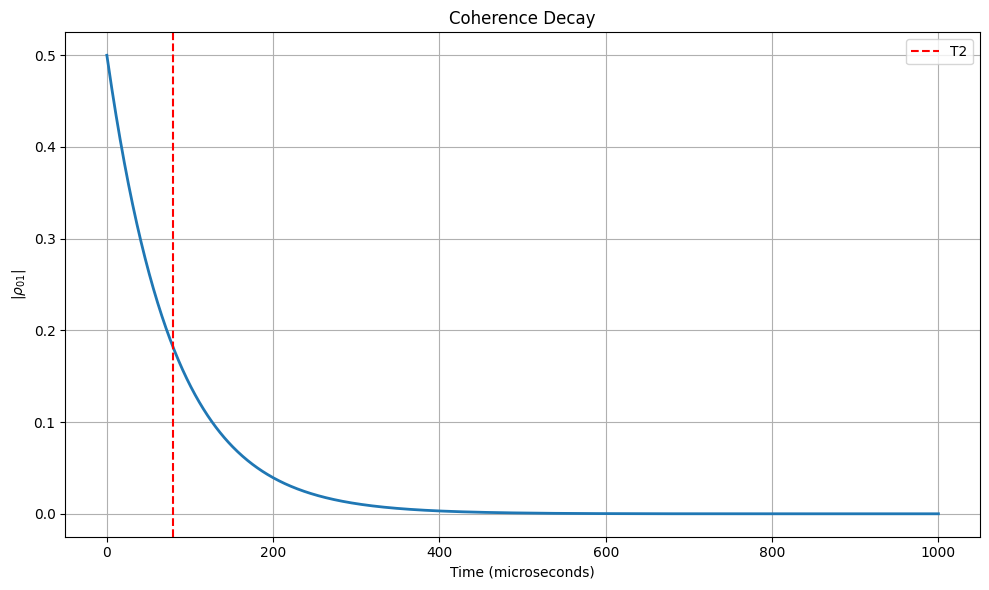

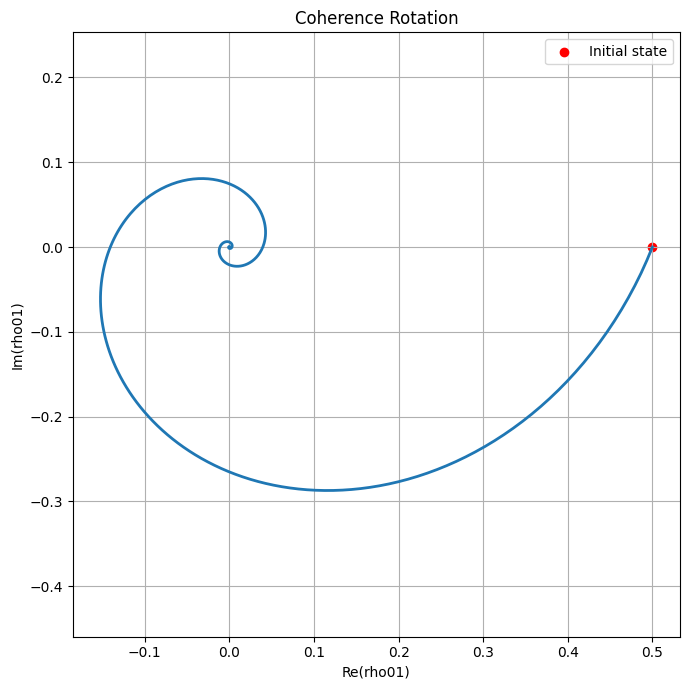

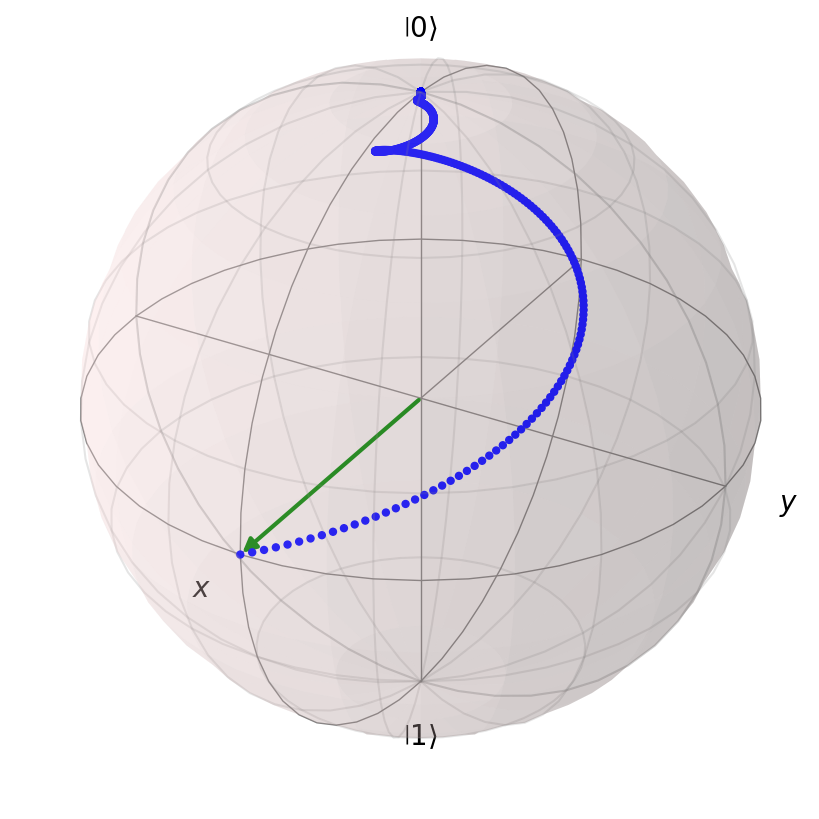



STEADY STATE

Final density matrix

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[9.99977300e-01+0.00000000e+00j 6.82119044e-06+1.23765792e-05j]
 [6.82119044e-06-1.23765792e-05j 2.26999649e-05+0.00000000e+00j]]

Expected ground state

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]

Difference = 5.3478846557467835e-05

Maximum trace error = 2.220446049250313e-16


In [ ]:
# ============================================================
# TASK 2 : Lindblad Simulation of a Superconducting Qubit
# PART 1
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from qutip import (
    basis,
    ket2dm,
    sigmax,
    sigmay,
    sigmaz,
    sigmam,
    sigmap,
    mesolve,
    expect,
    Bloch,
)

# ============================================================
# defining physical parameters
# ============================================================

freq = 5000 #converting 5 GHZ to MHZ as time is taken in u seconds

omega = 2 * np.pi * freq    # rad/us  (kept only for reference/printing)

T1 = 100.0
T2 = 80.0

gamma1 = 1 / T1
gamma_phi = (1 / T2) - (1 / (2 * T1))


print("PHYSICAL PARAMETERS")


print(f"Qubit frequency = {f_q_GHz} GHz")
print(f"T1 = {T1} us")
print(f"T2 = {T2} us")
print(f"gamma1 = {gamma1:.6f} /us")
print(f"gamma_phi = {gamma_phi:.6f} /us")

# taking input of Initial State



while True:
    alpha = complex(input("Enter alpha: "))
    beta = complex(input("Enter beta: "))

    norm = abs(alpha)**2 + abs(beta)**2

    if np.isclose(norm, 1):
        break

    print(f"\nState not normalized.")
    print(f"|alpha|² + |beta|² = {norm:.6f}")
    print("Please enter normalized amplitudes.\n")
psi0 = alpha * basis(2, 0) + beta * basis(2, 1)
rho0 = ket2dm(psi0)

print("\nInitial density matrix\n")
print(rho0)

# ============================================================
# Hamiltonian
# ============================================================

 """if we consider 5ghz as frequency of oscillation then it will be very hard to compute as the oscillations will be alot faster ,
 that is why we consider a rotating frame of 4995 f and hence we define delta to define hamiltonian, thus effective omega is 2pie(5mhz)"""

delta_omega = 2 * np.pi * 5.0   # 5 MHz detuning, rad/us
H = (delta / 2) * sigmaz()

print("\nHamiltonian (rotating frame, 5 MHz detuning)\n")
print(H)

# ============================================================
# Collapse operators
# ============================================================
"""we define collapse operators to introduce the effect of noise"""
c_ops = [ np.sqrt(gamma1).sigmap, (np.sqrt(gamma_phi)/2).sigmaz]


"this list contains the time values for which we'll extract the density matrix from mesolve"

tlist = np.linspace(0,3*T1, 30)
#Now , we will use mesolve to solve the linblad master equation and get the density matrix at time instances in tlist
result = mesolve(H,rho0,tlist,c_ops)

print("\nSimulation completed successfully!")
print(f"Stored {len(result.states)} density matrices.")

# ============================================================
# Extract information from density matrices that we got from mesolve
# ============================================================

density_matrices = result.states

P0, P1 = [], []
rho01, rho10 = [], []
coherence = []
bloch_x, bloch_y, bloch_z = [], [], []

for rho in density_matrices:
    matrix = rho.full()

    P0.append(np.real(matrix[0, 0]))
    P1.append(np.real(matrix[1, 1]))

    rho01.append(matrix[0, 1])
    rho10.append(matrix[1, 0])

    coherence.append(abs(matrix[0, 1]))

    bloch_x.append(expect(sigmax(), rho))
    bloch_y.append(expect(sigmay(), rho))
    bloch_z.append(expect(sigmaz(), rho))

P0 = np.array(P0)
P1 = np.array(P1)
rho01 = np.array(rho01)
rho10 = np.array(rho10)
coherence = np.array(coherence)
bloch_x = np.array(bloch_x)
bloch_y = np.array(bloch_y)
bloch_z = np.array(bloch_z)

# ============================================================
# Density matrices at important times
# ============================================================

print("\n")
print("=" * 60)
print("DENSITY MATRICES")
print("=" * 60)

times = [0, T2, T1, 2 * T1]

for t in times:
    idx = np.argmin(np.abs(tlist - t))
    print(f"\nTime = {tlist[idx]:.2f} us")
    print(density_matrices[idx])
    print("Trace =", density_matrices[idx].tr())

# ============================================================
# now we map P0 and P1 with respct to time to understand what happens to prob amp in effect of noise
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(tlist, P0, label="Ground state population")
plt.plot(tlist, P1, label="Excited state population")
plt.axvline(T1, linestyle="--", color="black", label="T1")
plt.xlabel("Time (microseconds)")
plt.ylabel("Population")
plt.title("Population Evolution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("population_evolution.png", dpi=150)
plt.show()

# ============================================================
# we map the real value part of coherence as it decreases witht time
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(tlist, coherence, linewidth=2)
plt.axvline(T2, linestyle="--", color="red", label="T2")
plt.xlabel("Time (microseconds)")
plt.ylabel(r"$|\rho_{01}|$")
plt.title("Coherence Decay")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("coherence_decay.png", dpi=150)
plt.show()

# ============================================================
#
# ============================================================

plt.figure(figsize=(7, 7))
plt.plot(np.real(rho01), np.imag(rho01), linewidth=2)
plt.scatter(np.real(rho01[0]), np.imag(rho01[0]), color="red", label="Initial state")
plt.xlabel("Re(rho01)")
plt.ylabel("Im(rho01)")
plt.title("Coherence Rotation")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.savefig("coherence_rotation.png", dpi=150)
plt.show()

# ============================================================
# Bloch vector
# ============================================================

fig = plt.figure(figsize=(8, 8))
b = Bloch(fig=fig)
b.add_points([bloch_x, bloch_y, bloch_z])
b.add_vectors([bloch_x[0], bloch_y[0], bloch_z[0]])
b.render()
plt.savefig("bloch_sphere.png", dpi=150)
plt.show()

# ============================================================
# Steady state verification
# ============================================================

rho_final = density_matrices[-1]
expected = ket2dm(basis(2, 0))
difference = (rho_final - expected).norm()

print("\n")
print("=" * 60)
print("STEADY STATE")
print("=" * 60)
print("\nFinal density matrix\n")
print(rho_final)
print("\nExpected ground state\n")
print(expected)
print("\nDifference =", difference)

# ============================================================
# Trace preservation
# ============================================================

trace_error = [abs(rho.tr() - 1) for rho in density_matrices]
print("\nMaximum trace error =", max(trace_error))

Estimated T1 = 97.30 ± 5.52 μs (95% CI)
[1.0, 0.913, 0.825, 0.727, 0.654, 0.606, 0.502, 0.506, 0.434, 0.381, 0.362, 0.331, 0.293, 0.248, 0.207, 0.217, 0.159, 0.162, 0.17, 0.124, 0.123, 0.131, 0.107, 0.082, 0.096, 0.069, 0.057, 0.06, 0.051, 0.059]


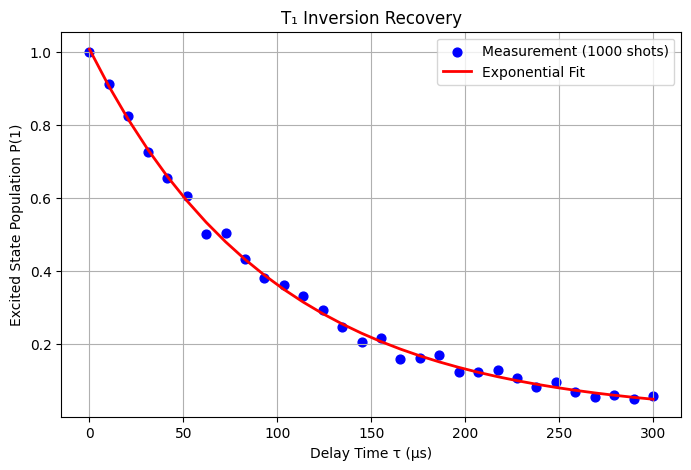

In [ ]:
# measuring T1
from qutip.measurement import measure
from scipy.optimize import curve_fit
# setting initial state ket1, instead of first setting ket0 and then applying rx gate to get ket1. psi0 means state at t = 0
psi0 = basis(2, 1)
rho0 = ket2dm(psi0)

# Delay times
tau = np.linspace(0, 3*T1, 30)

# applying mesolve to get the density matrix at each time in the list tau
result = mesolve(H,rho0,tau,c_ops=c_ops,)

# As we want measurment along basis 0 and 1
projectors = [ket2dm(basis(2,0)),ket2dm(basis(2,1))]

shots = 1000
P1 = []
#taking measurment of each state that we get for time in tau 1000 times
for rho in result.states:
  count_1 = 0
  for _ in range(shots):
   outcome,collapsed_state = measure(rho.copy(),projectors)
   if outcome == 1:
     count_1 += 1
  P1.append(count_1 / shots)
# -----------------------------
# extracting T1 using curve fitting
# -----------------------------

def exp_decay(t, A, T1_fit, B):
    return A * np.exp(-t / T1_fit) + B

initial_guess = [1.0, T1, 0.0]

params, covariance = curve_fit(
    exp_decay,
    tau,
    P1,
    p0=initial_guess
)

A_fit, T1_fit, B_fit = params

errors = np.sqrt(np.diag(covariance))
T1_error = errors[1]
CI95 = 1.96 * T1_error

print(f"Estimated T1 = {T1_fit:.2f} ± {CI95:.2f} μs (95% CI)")
# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    tau,
    P1,
    color="blue",
    s=40,
    label=f"Measurement ({shots} shots)"
)

plt.plot(
    tau,
    exp_decay(tau, *params),
    "r-",
    linewidth=2,
    label="Exponential Fit"
)

plt.xlabel("Delay Time τ (μs)")
plt.ylabel("Excited State Population P(1)")
plt.title("T₁ Inversion Recovery")
plt.grid(True)
plt.legend()
print(P1)



